# 01 — Exploratory Data Analysis

Exploratory analysis of the NASA SMAP/MSL telemetry anomaly dataset. We inspect entity metadata, time series lengths, channel counts, anomaly class distributions, and anomaly density — without any preprocessing.

In [1]:
import os
import re
import ast
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATA_DIR = Path("data")
LABELS_FILE = Path("labeled_anomalies.csv")

## Dataset Overview

In [2]:
df_labels = pd.read_csv(LABELS_FILE)

df_labels["anomaly_sequences"] = df_labels["anomaly_sequences"].apply(ast.literal_eval)
df_labels["class"] = df_labels["class"].apply(
    lambda v: re.findall(r"[a-z]+", v) if isinstance(v, str) else v
)

print(f"Total entities: {len(df_labels)}")
print()
print("Per-spacecraft counts:")
print(df_labels["spacecraft"].value_counts().to_string())
print()
all_classes = [c for classes in df_labels["class"] for c in classes]
class_counts = Counter(all_classes)
print("Anomaly class distribution:")
for cls, cnt in sorted(class_counts.items()):
    print(f"  {cls}: {cnt}")

Total entities: 82

Per-spacecraft counts:
spacecraft
SMAP    55
MSL     27

Anomaly class distribution:
  contextual: 43
  point: 62


In [3]:
records = []
for _, row in df_labels.iterrows():
    chan_id = row["chan_id"]
    train_path = DATA_DIR / "train" / f"{chan_id}.npy"
    test_path = DATA_DIR / "test" / f"{chan_id}.npy"
    train_data = np.load(train_path)
    test_data = np.load(test_path)
    n_channels = train_data.shape[1] if train_data.ndim > 1 else 1
    records.append({
        "chan_id": chan_id,
        "spacecraft": row["spacecraft"],
        "n_channels": n_channels,
        "train_len": len(train_data),
        "test_len": len(test_data),
        "n_anomaly_segments": len(row["anomaly_sequences"]),
    })

df = pd.DataFrame(records)
print(df.head(10).to_string())
print()
print(df[["n_channels", "train_len", "test_len", "n_anomaly_segments"]].describe())

  chan_id spacecraft  n_channels  train_len  test_len  n_anomaly_segments
0     P-1       SMAP          25       2872      8505                   3
1     S-1       SMAP          25       2818      7331                   1
2     E-1       SMAP          25       2880      8516                   2
3     E-2       SMAP          25       2880      8532                   1
4     E-3       SMAP          25       2880      8307                   1
5     E-4       SMAP          25       2880      8354                   1
6     E-5       SMAP          25       2880      8294                   1
7     E-6       SMAP          25       2880      8300                   1
8     E-7       SMAP          25       2769      8310                   1
9     E-8       SMAP          25       2880      8532                   1

       n_channels    train_len     test_len  n_anomaly_segments
count   82.000000    82.000000    82.000000           82.000000
mean    34.878049  2428.560976  6314.195122            1.

## Channel Count Distribution

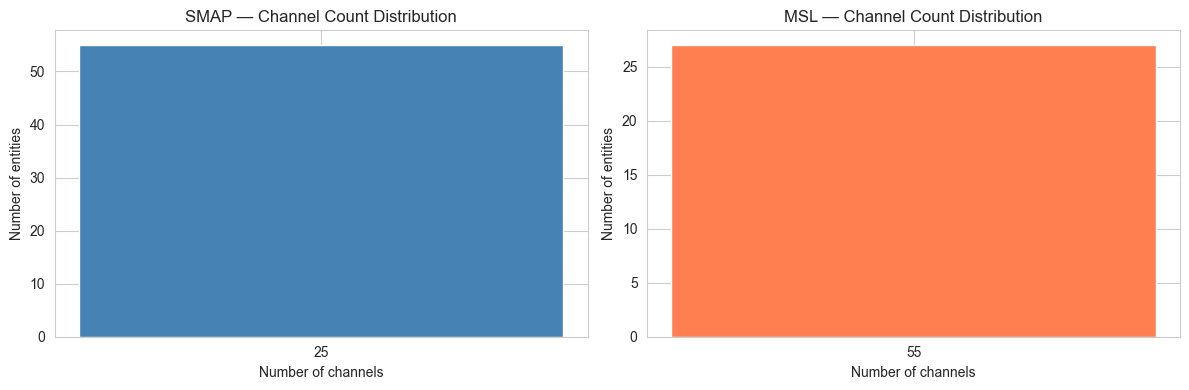

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, spacecraft in zip(axes, ["SMAP", "MSL"]):
    subset = df[df["spacecraft"] == spacecraft]
    channel_counts = subset["n_channels"].value_counts().sort_index()
    ax.bar(channel_counts.index.astype(str), channel_counts.values, color="steelblue" if spacecraft == "SMAP" else "coral")
    ax.set_title(f"{spacecraft} — Channel Count Distribution")
    ax.set_xlabel("Number of channels")
    ax.set_ylabel("Number of entities")

plt.tight_layout()
plt.show()

## Time Series Length Distribution

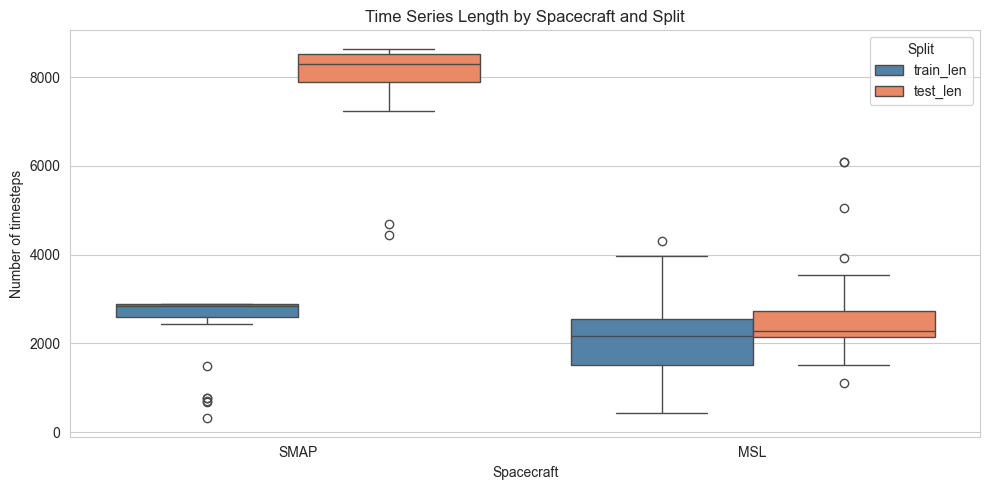

In [5]:
df_melted = df.melt(
    id_vars=["chan_id", "spacecraft"],
    value_vars=["train_len", "test_len"],
    var_name="split",
    value_name="length",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_melted,
    x="spacecraft",
    y="length",
    hue="split",
    palette={"train_len": "steelblue", "test_len": "coral"},
    ax=ax,
)
ax.set_title("Time Series Length by Spacecraft and Split")
ax.set_xlabel("Spacecraft")
ax.set_ylabel("Number of timesteps")
ax.legend(title="Split")
plt.tight_layout()
plt.show()

## Anomaly Segment Visualization

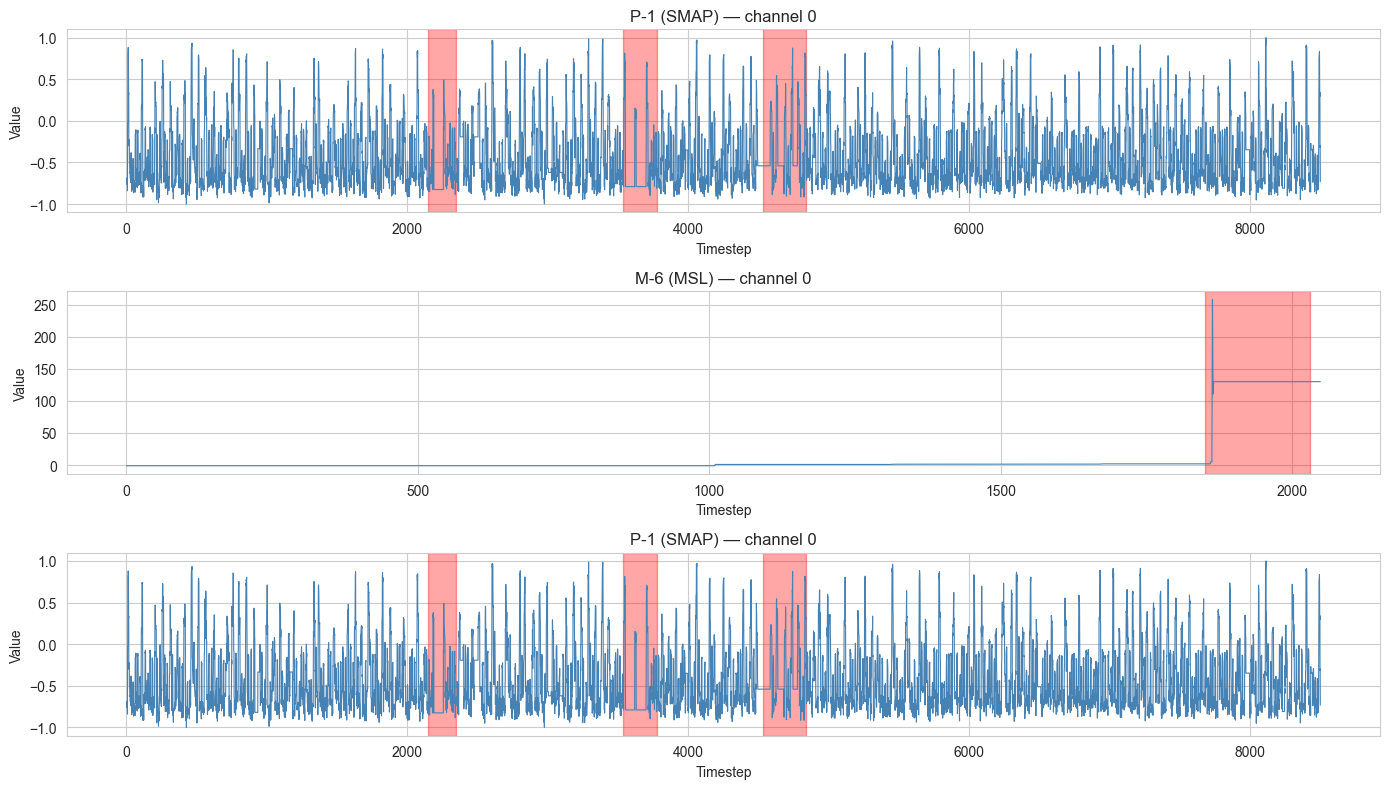

In [6]:
smap_entity = df[df["spacecraft"] == "SMAP"].iloc[0]["chan_id"]
msl_entity = df[df["spacecraft"] == "MSL"].iloc[0]["chan_id"]
multi_seg_entity = df[df["n_anomaly_segments"] > 2].iloc[0]["chan_id"]

entities_to_plot = [smap_entity, msl_entity, multi_seg_entity]
label_map = {row["chan_id"]: row for _, row in df_labels.iterrows()}

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for ax, chan_id in zip(axes, entities_to_plot):
    test_data = np.load(DATA_DIR / "test" / f"{chan_id}.npy")
    channel_0 = test_data[:, 0] if test_data.ndim > 1 else test_data
    ax.plot(channel_0, linewidth=0.8, color="steelblue")
    row = label_map[chan_id]
    for start, end in row["anomaly_sequences"]:
        ax.axvspan(start, end, alpha=0.35, color="red", label="anomaly")
    spacecraft = df[df["chan_id"] == chan_id]["spacecraft"].values[0]
    ax.set_title(f"{chan_id} ({spacecraft}) — channel 0")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

## Anomaly Density per Entity

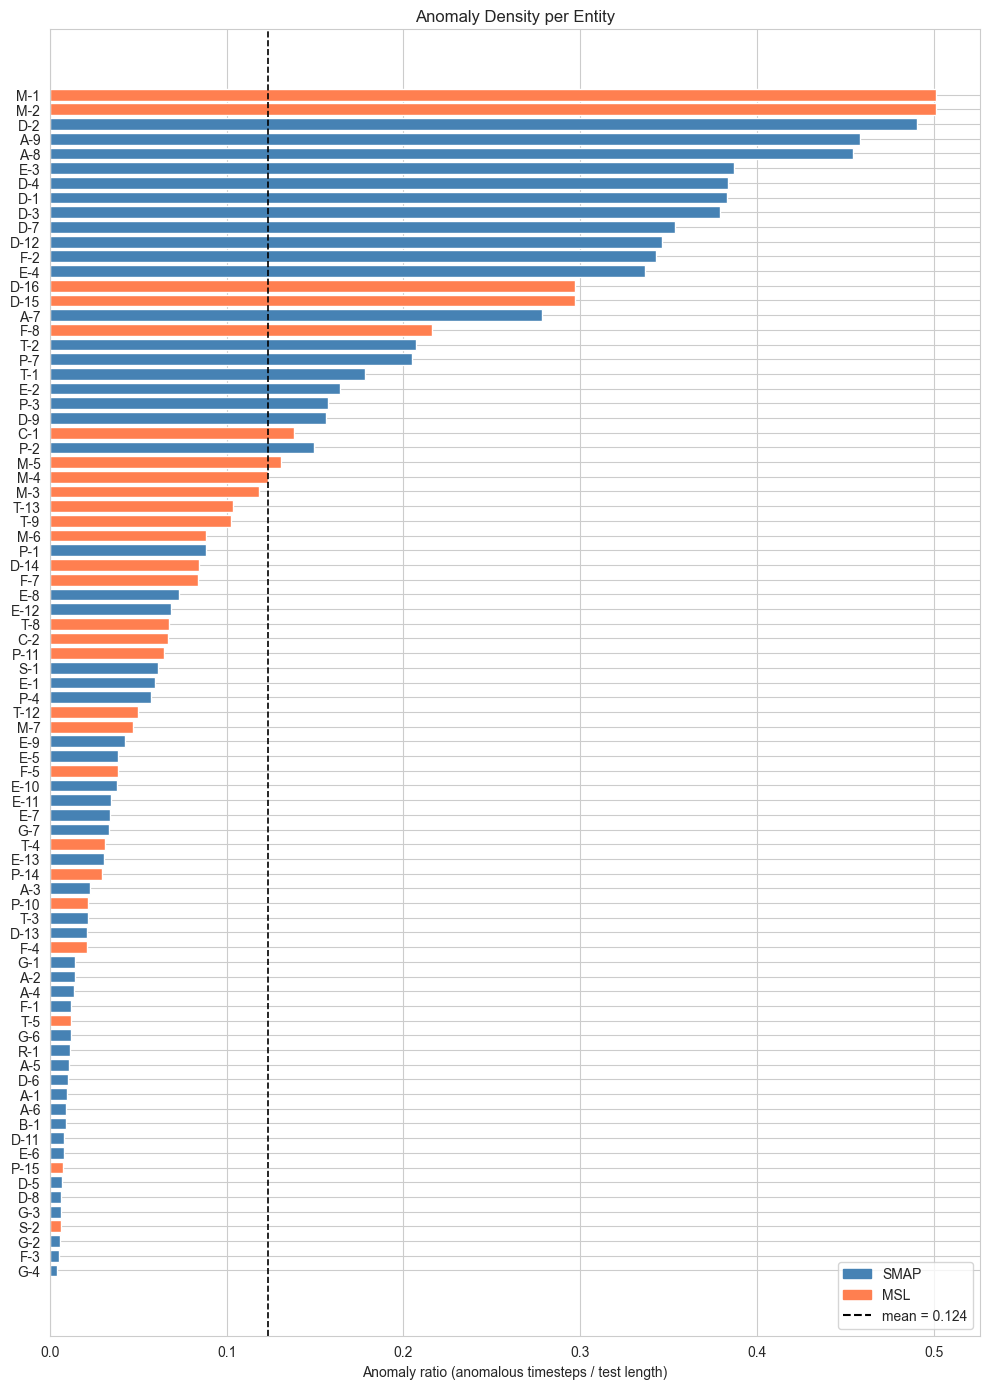

In [8]:
def total_anomalous_timesteps(sequences):
    return sum(end - start + 1 for start, end in sequences)

df_labels_merged = df_labels.merge(df[["chan_id", "test_len"]], on="chan_id")
df_labels_merged["anomaly_ratio"] = df_labels_merged.apply(
    lambda r: total_anomalous_timesteps(r["anomaly_sequences"]) / r["test_len"], axis=1
)
df_labels_merged = df_labels_merged.sort_values("anomaly_ratio", ascending=True)

palette = {"SMAP": "steelblue", "MSL": "coral"}
colors = df_labels_merged["spacecraft"].map(palette)
mean_ratio = df_labels_merged["anomaly_ratio"].mean()

fig, ax = plt.subplots(figsize=(10, 14))
ax.barh(df_labels_merged["chan_id"], df_labels_merged["anomaly_ratio"], color=colors)
ax.axvline(mean_ratio, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Anomaly ratio (anomalous timesteps / test length)")
ax.set_title("Anomaly Density per Entity")

from matplotlib.patches import Patch
legend_handles = [
    Patch(color="steelblue", label="SMAP"),
    Patch(color="coral", label="MSL"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"mean = {mean_ratio:.3f}"),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

## Summary

In [9]:
smap_count = (df["spacecraft"] == "SMAP").sum()
msl_count = (df["spacecraft"] == "MSL").sum()
typical_train = df["train_len"].median()
typical_test = df["test_len"].median()
ratio_min = df_labels_merged["anomaly_ratio"].min()
ratio_max = df_labels_merged["anomaly_ratio"].max()

print("=" * 45)
print("Dataset Summary")
print("=" * 45)
print(f"Window size (for modeling): 100")
print(f"Total entities:            {len(df)}")
print(f"  SMAP:                    {smap_count}")
print(f"  MSL:                     {msl_count}")
print(f"Typical train length:      {int(typical_train):,} timesteps (median)")
print(f"Typical test length:       {int(typical_test):,} timesteps (median)")
print(f"Anomaly ratio range:       {ratio_min:.3f} – {ratio_max:.3f}")
print("=" * 45)

Dataset Summary
Window size (for modeling): 100
Total entities:            82
  SMAP:                    55
  MSL:                     27
Typical train length:      2,713 timesteps (median)
Typical test length:       7,895 timesteps (median)
Anomaly ratio range:       0.004 – 0.501
